In [1]:
import torch
import numpy as np
import pandas as pd
import networkx as nx

from utils import load_graph_from_txt
from pathlib import Path
from vis import Plotter
import matplotlib.pyplot as plt

from utils import load_graph_from_txt, compute_neighbor_loss_over_records

In [2]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_tree_numbers"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_bin_tree_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 15 #archi: 14


In [3]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "tree_numbers"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_{structure_name}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 15 #archi: 14


In [4]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_grid_numbers"
structure_name = "grid"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_grid_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_grid_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 15 #archi: 22


In [5]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "circle_numbers"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_numbers_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

circle_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 15 #archi: 15


In [6]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "shuffled_circle_numbers"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_numbers_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_circle_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 15 #archi: 15


Grid - #nodi: 15 #archi: 22


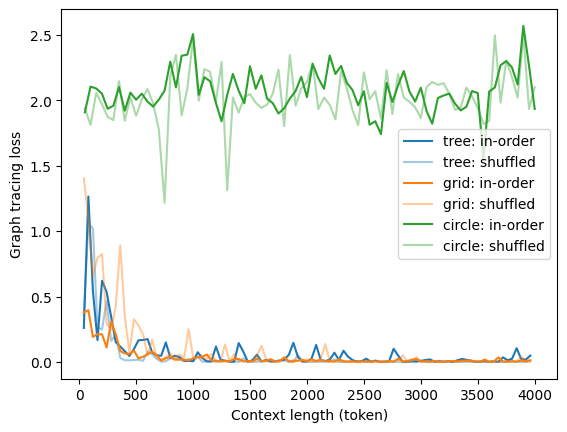

In [24]:
VOCAB_PATH = Path("../data/number_ids.txt")

grid_folder = "grid_numbers"
structure_name = "grid"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_{grid_folder}_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])


summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

grid_numbers_loss = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

tree_color = "tab:blue"
grid_color = "tab:orange"

plt.figure()

# TREE (stesso colore, uno più chiaro)
plt.plot(tree_numbers_loss[:, 0], tree_numbers_loss[:, 1],
         label="tree: in-order", color=tree_color, alpha=1.0)
plt.plot(shuffled_tree_numbers_loss[:, 0], shuffled_tree_numbers_loss[:, 1],
         label="tree: shuffled", color=tree_color, alpha=0.4)

# GRID (stesso colore, uno più chiaro)
plt.plot(grid_numbers_loss[:, 0], grid_numbers_loss[:, 1],
         label="grid: in-order", color=grid_color, alpha=1.0)
plt.plot(shuffled_grid_numbers_loss[:, 0], shuffled_grid_numbers_loss[:, 1],
         label="grid: shuffled", color=grid_color, alpha=0.4)

plt.plot(circle_numbers_loss[:80, 0], circle_numbers_loss[:80, 1],
         label="circle: in-order", color="tab:green", alpha=1.0)
plt.plot(shuffled_circle_numbers_loss[:80, 0], shuffled_circle_numbers_loss[:80, 1],
         label="circle: shuffled", color="tab:green", alpha=0.4)

plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
plt.show()

fissato un grafo la versione shuffled è sempre più alta di quella in order (fino a 1500 circa). quando poi va a plateau va tutto a zero meaning that fa meglio ntp ma le rappresentazioni geometriche posso essere la qualunque. Citare questa roba nelle conclusioni

## DAYS

In [8]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "circle_days"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_days_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

circle_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 7 #archi: 7


In [9]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "shuffled_circle_days"
structure_name = "circle"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="cycle")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_circle_days_shuffled_one_rw_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

shuffled_circle_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

Grid - #nodi: 7 #archi: 7


Grid - #nodi: 7 #archi: 6


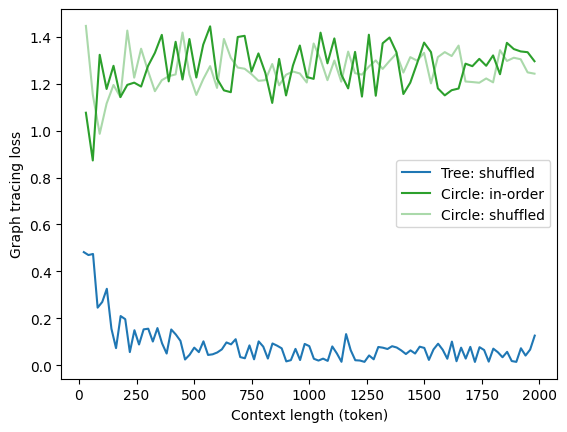

In [21]:
VOCAB_PATH = Path("../data/days_tkid_map.txt")

grid_folder = "tree_days"
structure_name = "bin_tree"

EMB_DIR    = Path(f"../embeddings/new/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

logit_file = EMB_DIR / f"final_topk_pairAB_step10_bin_tree_days_dataset_2000.pt"

# Carica records top-k
data = torch.load(logit_file, map_location="cpu")
records = data.get("records", [])

summary, df_loss = compute_neighbor_loss_over_records(
    records, G,
    topk_field="top_decoded",
    probs_field="top_probs",
    lowercase=True,
)

df = df_loss.copy()

# usa la posizione nel prompt come proxy della "lunghezza del contesto"
df["length_tokens"] = df["token_position_1based"].astype(int)

# filtra record validi
mask = df["ok"].astype(bool) & np.isfinite(df["loss_topk"].astype(float))
dfv = df.loc[mask].sort_values("length_tokens")

tree_day = dfv[["length_tokens", "loss_topk"]].copy().to_numpy()

plt.figure()
plt.plot(tree_day[:, 0], tree_day[:, 1], label="Tree: shuffled")
plt.plot(circle_day[:66, 0], circle_day[:66, 1], label="Circle: in-order", color="tab:green")
plt.plot(shuffled_circle_day[:66, 0], shuffled_circle_day[:66, 1], label="Circle: shuffled", color="tab:green", alpha=0.4)
plt.legend()
plt.xlabel("Context length (token)")
plt.ylabel("Graph tracing loss")
plt.show()